In [1]:
import numpy as np
import pandas as pd

np.random.seed(1234)


In [2]:
# 데이터 로드
df = pd.read_csv("../data/creditcard.csv")

print("Length:", len(df))
df.head()


Length: 284807


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.shape
# 총 284,807행, 31개 컬럼 (Time, V1~V28, Amount, Class)


(284807, 31)

In [4]:
df.info()
# 전부 float64 / int64 -> 문자형(object) 컬럼 없음
# Non-Null Count가 전부 284807이면 결측치가 없다는 뜻 -> 아래에서 isnull()로 재확인


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
# PCA 처리된 컬럼 확인 (V1~V28)
# 근거: ① 평균이 거의 0  ② 서로 상관관계가 거의 없음(직교) -> PCA 변환의 전형적인 특징
v_cols = [c for c in df.columns if c.startswith("V")]

print("V1~V28 평균 절대값 최대:", df[v_cols].mean().abs().max())
print("V1~V28 상관계수 절대값 최대(자기 자신 제외):",
      df[v_cols].corr().where(~np.eye(len(v_cols), dtype=bool)).abs().max().max())

# => V1~V28(28개)만 PCA로 변환된 익명 피처, Time/Amount는 원본 컬럼, Class는 타겟
#
# [PCA 컬럼이 이후 전처리/모델링에 미치는 영향]
# - 이미 평균 0이지만 컬럼별 표준편차는 서로 다름(V1≈1.95 ~ V28≈0.33, explained variance 순서)
#   -> 로지스틱회귀/KNN/SVM처럼 스케일에 민감한 모델을 쓴다면 StandardScaler로 한 번 더 맞춰주는 게 안전
#   -> RandomForest/XGBoost/LightGBM 같은 트리 기반 모델은 스케일 영향을 안 받아 그대로 사용 가능
# - PCA 성분끼리는 이미 직교(무상관)라서 V1~V28 사이의 다중공선성(multicollinearity)은 걱정할 필요 없음
# - 이미 익명화된 조합 변수라 원래 의미(어떤 거래 속성인지)를 알 수 없어, 개별 성분 단위의 도메인 기반
#   피처 엔지니어링은 불가능함 (feature importance로 "V14가 중요하다" 정도만 알 수 있고 비즈니스 해석은 불가)


V1~V28 평균 절대값 최대: 4.866698941746315e-15


V1~V28 상관계수 절대값 최대(자기 자신 제외): 2.321486470875369e-14


In [6]:
df.describe()
# V1~V28은 PCA로 변환된 익명 피처라서 평균이 거의 0에 가까움
# -> mean 값이 3.919560e-15 처럼 지수(e) 표기로 출력되어 한눈에 비교하기 어려움


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [7]:
# 지수(e) 표기 처리
# 기본 pandas 출력은 아주 작은 값(예: e-15)을 지수 표기로 보여줘서 가독성이 떨어짐
# -> 소수점 표기로 통일해서 보기 쉽게 설정
pd.set_option("display.float_format", lambda x: "%.4f" % x)

df.describe()
# 위와 동일한 값이지만 e-15 같은 지수 표기 없이 0.0000 형태로 표시됨


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,...,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000
mean,94813.8596,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000,...,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,-0.0000,88.3496,0.0017
std,47488.1460,1.9587,1.6513,1.5163,1.4159,1.3802,1.3323,1.2371,1.1944,1.0986,...,0.7345,0.7257,0.6245,0.6056,0.5213,0.4822,0.4036,0.3301,250.1201,0.0415
min,0.0000,-56.4075,-72.7157,-48.3256,-5.6832,-113.7433,-26.1605,-43.5572,-73.2167,-13.4341,...,-34.8304,-10.9331,-44.8077,-2.8366,-10.2954,-2.6046,-22.5657,-15.4301,0.0000,0.0000
25%,54201.5000,-0.9204,-0.5985,-0.8904,-0.8486,-0.6916,-0.7683,-0.5541,-0.2086,-0.6431,...,-0.2284,-0.5424,-0.1618,-0.3546,-0.3171,-0.3270,-0.0708,-0.0530,5.6000,0.0000
50%,84692.0000,0.0181,0.0655,0.1798,-0.0198,-0.0543,-0.2742,0.0401,0.0224,-0.0514,...,-0.0295,0.0068,-0.0112,0.0410,0.0166,-0.0521,0.0013,0.0112,22.0000,0.0000
75%,139320.5000,1.3156,0.8037,1.0272,0.7433,0.6119,0.3986,0.5704,0.3273,0.5971,...,0.1864,0.5286,0.1476,0.4395,0.3507,0.2410,0.0910,0.0783,77.1650,0.0000
max,172792.0000,2.4549,22.0577,9.3826,16.8753,34.8017,73.3016,120.5895,20.0072,15.5950,...,27.2028,10.5031,22.5284,4.5845,7.5196,3.5173,31.6122,33.8478,25691.1600,1.0000


In [8]:
# 타겟(Class) 분포 확인
print(df["Class"].value_counts())
print()
print(df["Class"].value_counts(normalize=True))

# Class = 0 (정상 거래) : 약 99.83%
# Class = 1 (사기 거래) : 약 0.17%  -> 극단적인 클래스 불균형


Class
0    284315
1       492
Name: count, dtype: int64

Class
0   0.9983
1   0.0017
Name: proportion, dtype: float64


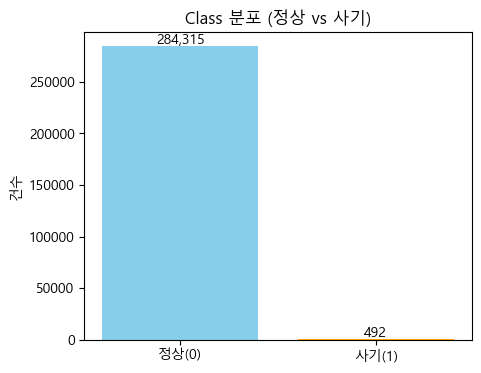

In [9]:
# Class 분포 시각화
import matplotlib.pyplot as plt

# 그래프에 한글이 깨지지 않도록 폰트 설정 (Windows 기본 한글 폰트)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

class_counts = df["Class"].value_counts()

plt.figure(figsize=(5, 4))
plt.bar(["정상(0)", "사기(1)"], class_counts.values, color=["skyblue", "orange"])
plt.title("Class 분포 (정상 vs 사기)")
plt.ylabel("건수")
for i, v in enumerate(class_counts.values):
    plt.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.show()


In [10]:
# 결측치 확인
print("컬럼별 결측치 개수:")
print(df.isnull().sum())

print("\n결측치가 있는 컬럼 수:", (df.isnull().sum() > 0).sum())
# 결측치 없음 확인 -> 별도의 결측치 대체(imputation)는 불필요


컬럼별 결측치 개수:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

결측치가 있는 컬럼 수: 0


In [11]:
# Time 컬럼 확인 및 제거
# Time은 첫 거래 시점부터 누적된 경과 초(0~172,792)일 뿐, 실제 시각(시/분)이 아니라서
# 그 자체로는 사기 여부와 직접적인 관계를 갖는 피처로 보기 어려움 + 값이 시간순으로 계속 증가하므로
# 그대로 학습에 쓰면 특정 시간대에 과적합될 위험도 있음
# -> 중복행 확인/제거에 들어가기 전에 먼저 Time 컬럼을 제거
#    (Time을 남긴 채로 중복을 제거하면, Time만 다르고 나머지 30개 컬럼이 같은 행을
#     서로 다른 행으로 잘못 취급해서 중복행이 과소 집계됨)
print(df["Time"].describe())

df = df.drop(columns=["Time"])
print("\nTime 컬럼 제거 후 shape:", df.shape)


count   284807.0000
mean     94813.8596
std      47488.1460
min          0.0000
25%      54201.5000
50%      84692.0000
75%     139320.5000
max     172792.0000
Name: Time, dtype: float64

Time 컬럼 제거 후 shape: (284807, 30)


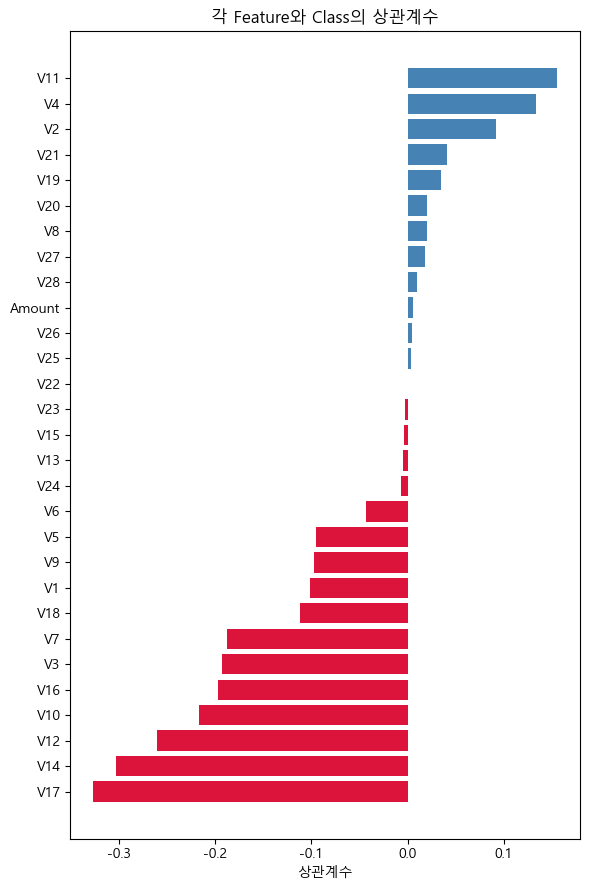

V17      -0.3265
V14      -0.3025
V12      -0.2606
V10      -0.2169
V16      -0.1965
V3       -0.1930
V7       -0.1873
V18      -0.1115
V1       -0.1013
V9       -0.0977
V5       -0.0950
V6       -0.0436
V24      -0.0072
V13      -0.0046
V15      -0.0042
V23      -0.0027
V22       0.0008
V25       0.0033
V26       0.0045
Amount    0.0056
V28       0.0095
V27       0.0176
V8        0.0199
V20       0.0201
V19       0.0348
V21       0.0404
V2        0.0913
V4        0.1334
V11       0.1549
Name: Class, dtype: float64


In [12]:
# Feature-Class 상관관계 확인 - 어떤 컬럼이 사기 여부와 관련이 깊은지 파악
corr_with_class = df.corr()["Class"].drop("Class").sort_values()

plt.figure(figsize=(6, 9))
colors = ["crimson" if v < 0 else "steelblue" for v in corr_with_class.values]
plt.barh(corr_with_class.index, corr_with_class.values, color=colors)
plt.title("각 Feature와 Class의 상관계수")
plt.xlabel("상관계수")
plt.tight_layout()
plt.show()

print(corr_with_class)
# V14, V17, V12, V10, V4, V11 등이 Class와 상관관계가 가장 강한 컬럼들
# -> 이 중 V14를 이상치 점검 대상으로 살펴봄


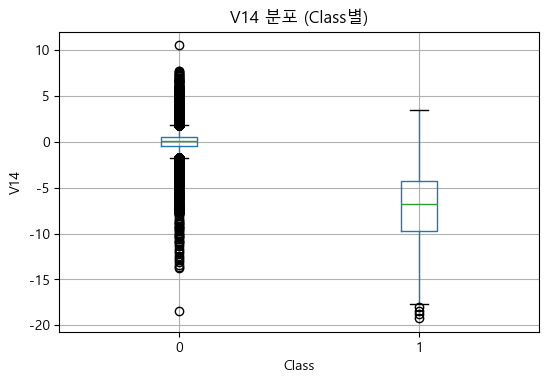

In [13]:
# V14 분포 확인 - Class별 boxplot (이상치가 어디 몰려있는지 시각적으로 확인)
df.boxplot(column="V14", by="Class", figsize=(6, 4))
plt.title("V14 분포 (Class별)")
plt.suptitle("")
plt.xlabel("Class")
plt.ylabel("V14")
plt.show()
# Class=1(사기)쪽에 아래로 크게 벗어난 극단값들이 보임 -> 아래 셀에서 이상치로 확인/제거


In [14]:
# V14 이상치 제거 (사기 케이스 기준)
# 사기(Class=1) 케이스만 떼어서 V14의 IQR을 구하고, 하한(Q1 - 1.5*IQR) 아래로 떨어지는 값만 제거
# (V14가 Class와 상관관계가 가장 큰 컬럼 중 하나라, 극단적으로 벗어난 값이 실제 사기 패턴이라기보다
#  노이즈에 가까울 가능성이 있어 점검함 - 정상(Class=0) 쪽은 건드리지 않음)
# * 반드시 중복행 제거보다 먼저 함 - 중복 제거 후에는 사분위수 자체가 바뀌어서 같은 기준이라도 결과가 달라짐
fraud_v14 = df.loc[df["Class"] == 1, "V14"]
q1, q3 = fraud_v14.quantile(0.25), fraud_v14.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr

v14_outliers = df[(df["Class"] == 1) & (df["V14"] < lower_bound)]
print("V14 하한(사기 케이스 기준):", lower_bound)
print("제거 대상 행 수:", len(v14_outliers))
print(v14_outliers[["V14", "Class"]])

df = df.drop(index=v14_outliers.index)
print("\nV14 이상치 제거 후 shape:", df.shape)


V14 하한(사기 케이스 기준): -17.807576138200666
제거 대상 행 수: 4
          V14  Class
8296 -19.2143      1
8615 -18.8221      1
9035 -18.4938      1
9252 -18.0500      1

V14 이상치 제거 후 shape: (284803, 30)


In [15]:
# 중복행 확인 및 제거
dup_cnt = df.duplicated().sum()
print("중복행 개수:", dup_cnt)

df = df.drop_duplicates().reset_index(drop=True)
print("중복 제거 후 shape:", df.shape)

print("\n중복 제거 후 Class 분포:")
print(df["Class"].value_counts())


중복행 개수: 9144


중복 제거 후 shape: (275659, 30)

중복 제거 후 Class 분포:
Class
0    275190
1       469
Name: count, dtype: int64


In [16]:
# Amount 이상치(너무 높은/낮은 값) 확인 - min/max 기준
print("Amount 최소값:", df["Amount"].min())
print("Amount 최대값:", df["Amount"].max())

print("\nAmount가 가장 큰 상위 10건:")
print(df.sort_values("Amount", ascending=False)[["Amount", "Class"]].head(10))

print("\nClass별 Amount 통계:")
print(df.groupby("Class")["Amount"].describe())

# min = 0, max ≈ 25,691 -> 둘 다 실제로 발생 가능한 결제 금액대라 값 자체가 잘못 기록된 오류로 보기 어려움
# 최고액 상위 10건은 전부 Class=0(정상) 거래이고, Class=1(사기)의 max는 2,125.87로 오히려 훨씬 작음
# -> IQR 기준 "이상치"로 잡히는 고액 거래들은 실제로는 정상적인 고액 결제이며,
#    이 값들을 clip/제거하면 모델이 학습할 수 있는 금액 스케일 정보만 없어질 뿐 사기 탐지에는 도움이 안 됨
# => Amount 이상치 제거/클리핑은 불필요하다고 판단, 원본 값을 그대로 사용


Amount 최소값: 0.0
Amount 최대값: 25691.16

Amount가 가장 큰 상위 10건:
           Amount  Class
266126 25691.1600      0
57204  19656.5300      0
146633 18910.0000      0
45798  12910.9300      0
52838  11898.0900      0
164203 11789.8400      0
275123 10199.4400      0
221274 10000.0000      0
73074   8790.2600      0
238143  8787.0000      0

Class별 Amount 통계:
            count     mean      std    min    25%     50%      75%        max
Class                                                                        
0     275190.0000  90.5212 253.1985 0.0000 6.3900 23.7500  79.9000 25691.1600
1        469.0000 124.9198 261.0716 0.0000 1.0000 10.7000 105.9900  2125.8700


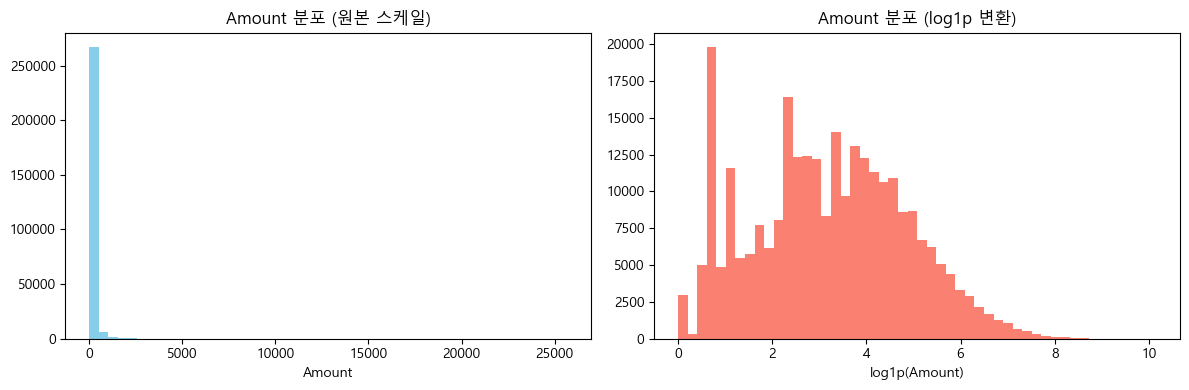

In [17]:
# Amount 분포 시각화 - 왜곡(skew) 정도를 원본/log 스케일로 비교
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["Amount"], bins=50, color="skyblue")
axes[0].set_title("Amount 분포 (원본 스케일)")
axes[0].set_xlabel("Amount")

axes[1].hist(np.log1p(df["Amount"]), bins=50, color="salmon")
axes[1].set_title("Amount 분포 (log1p 변환)")
axes[1].set_xlabel("log1p(Amount)")

plt.tight_layout()
plt.show()
# 원본 스케일은 대부분 0 근처에 몰려있고 꼬리가 아주 긺 -> log 변환하면 훨씬 정규분포에 가까워짐
# (다만 앞서 결정한 대로 Amount 자체는 클리핑/변환 없이 원본 값을 그대로 사용)


In [18]:
# 전처리 결과 최종 확인
print("전처리 완료 후 shape:", df.shape)
print("결측치 총합:", df.isnull().sum().sum())
print("중복행 총합:", df.duplicated().sum())

df.head()


전처리 완료 후 shape: (275659, 30)
결측치 총합: 0


중복행 총합: 0


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,...,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,...,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,...,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,...,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,...,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


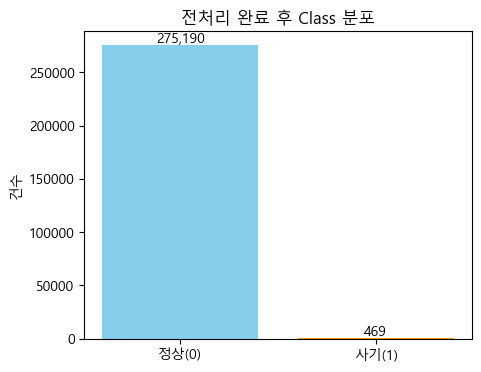

원본 Class 분포     : 정상 284,315 / 사기 492
전처리 후 Class 분포 : 정상 275,190 / 사기 469


In [19]:
# 전처리 완료 후 Class 분포 시각화 (V14 이상치 제거 + 중복행 제거 반영된 최종 상태)
final_class_counts = df["Class"].value_counts()

plt.figure(figsize=(5, 4))
plt.bar(["정상(0)", "사기(1)"], final_class_counts.values, color=["skyblue", "orange"])
plt.title("전처리 완료 후 Class 분포")
plt.ylabel("건수")
for i, v in enumerate(final_class_counts.values):
    plt.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.show()

print("원본 Class 분포     :", "정상 284,315 / 사기 492")
print(f"전처리 후 Class 분포 : 정상 {final_class_counts[0]:,} / 사기 {final_class_counts[1]:,}")


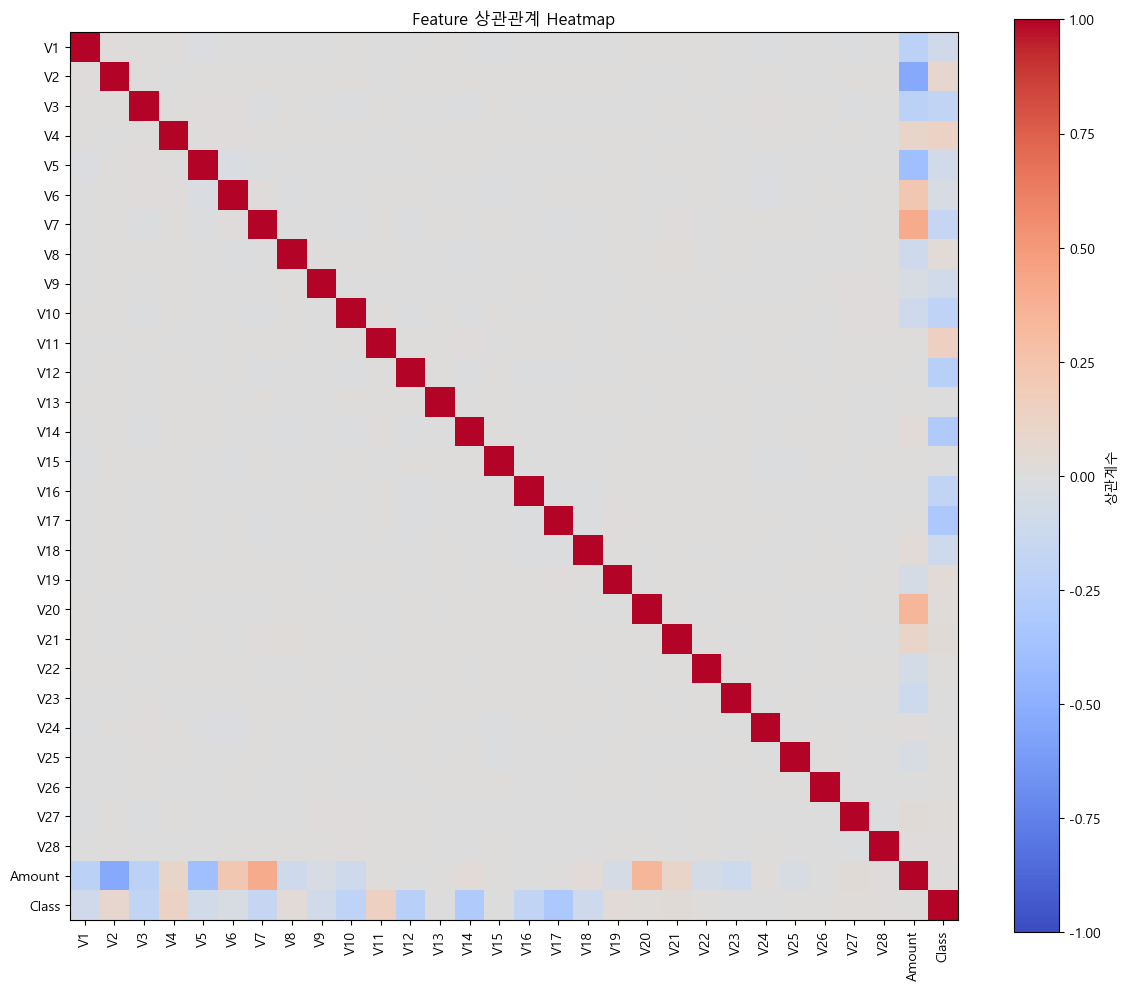

In [20]:
# 전처리 완료된 feature들의 상관관계 heatmap - 전체 관계를 한눈에 확인
feature_cols = df.columns
corr_matrix = df[feature_cols].corr()

plt.figure(figsize=(12, 10))
im = plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, label="상관계수")
plt.xticks(range(len(feature_cols)), feature_cols, rotation=90)
plt.yticks(range(len(feature_cols)), feature_cols)
plt.title("Feature 상관관계 Heatmap")
plt.tight_layout()
plt.show()

# V1~V28끼리는 거의 하얀색(무상관)인 게 PCA의 직교성과 일치
# Amount/Class만 스케일이 달라 상대적으로 눈에 띔


In [21]:
# Feature / Target 분리
X = df.drop(columns=["Class"])
y = df["Class"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (275659, 29)
y shape: (275659,)


In [22]:
# train/test 분리 - stratify로 극단적인 클래스 불균형(양성 0.17%)이 train/test에 동일 비율로 유지되게 함
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=0,
    stratify=y
)

print("X_train:", X_train.shape, " X_test:", X_test.shape)

print("\ntrain Class 비율:")
print(y_train.value_counts(normalize=True))

print("\ntest Class 비율:")
print(y_test.value_counts(normalize=True))


X_train: (220527, 29)  X_test: (55132, 29)

train Class 비율:
Class
0   0.9983
1   0.0017
Name: proportion, dtype: float64

test Class 비율:
Class
0   0.9983
1   0.0017
Name: proportion, dtype: float64


In [23]:
# 스케일링 - RobustScaler (V1~V28 + Amount 전체)
# Amount는 mean이 median의 4배(88 vs 22)일 정도로 심하게 skew돼 있고, 그 이상치를 일부러 유지하기로 했음
# -> 평균/표준편차 기반 StandardScaler는 그 소수의 이상치에 스케일 계산 자체가 끌려가 나머지 값들이 좁은 구간에 눌림
# -> 중앙값/IQR 기반이라 이상치에 덜 흔들리는 RobustScaler를 V1~V28 + Amount 전체에 통일해서 적용
# (반드시 train/test split 이후, train으로만 fit -> test는 transform만 해서 데이터 누수 방지)
# * 이 스케일된 버전은 SMOTE + LogisticRegression처럼 스케일에 민감한 모델 트랙에서만 사용
#   XGBoost/LightGBM 등 트리 기반 모델은 스케일 영향이 없으므로 원본 X_train/X_test를 그대로 사용
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("X_train_scaled shape:", X_train_scaled.shape)
X_train_scaled.describe()


X_train_scaled shape: (220527, 29)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
count,220527.0000,220527.0000,220527.0000,220527.0000,220527.0000,220527.0000,220527.0000,220527.0000,220527.0000,220527.0000,...,220527.0000,220527.0000,220527.0000,220527.0000,220527.0000,220527.0000,220527.0000,220527.0000,220527.0000,220527.0000
mean,0.0107,-0.0521,-0.0934,0.0195,0.0391,0.2222,-0.0323,-0.0544,0.0431,0.0933,...,0.1750,0.0698,-0.0080,0.0375,-0.0566,-0.0230,0.0979,-0.0045,-0.0807,0.9114
std,0.8727,1.1639,0.7952,0.8804,1.0435,1.1306,1.0763,2.2331,0.8777,1.0713,...,2.1999,1.7733,0.6818,2.0440,0.7641,0.7806,0.8458,2.3446,2.4874,3.4284
min,-25.1858,-50.7256,-17.8774,-3.4949,-32.2572,-22.4339,-38.3974,-137.8301,-10.6868,-24.2309,...,-79.4298,-84.2332,-10.2934,-117.9247,-3.6252,-12.9920,-4.4535,-58.7604,-71.8170,-0.3239
25%,-0.3933,-0.4786,-0.5531,-0.5116,-0.4895,-0.4286,-0.5252,-0.4382,-0.4732,-0.4430,...,-0.4380,-0.4814,-0.5124,-0.4881,-0.5027,-0.4987,-0.4755,-0.4470,-0.4798,-0.2365
50%,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
75%,0.6067,0.5214,0.4469,0.4884,0.5105,0.5714,0.4748,0.5618,0.5268,0.5570,...,0.5620,0.5186,0.4876,0.5119,0.4973,0.5013,0.5245,0.5530,0.5202,0.7635
max,1.1257,15.3215,2.1221,10.4638,26.7208,20.9603,38.7551,37.6073,8.3445,15.2582,...,112.1854,65.8971,9.8624,72.5282,5.0259,11.2036,6.2429,72.8775,252.3409,267.1847


In [24]:
# 모든 모델 비교/검증에 공통으로 재사용할 StratifiedKFold
# -> 어떤 모델이든 같은 fold 구성으로 평가해야 "모델 차이"를 공정하게 비교할 수 있음
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)


In [25]:
# LogisticRegression (class_weight="balanced") - StratifiedKFold CV
# SMOTE 없이, 이미 전체로 스케일링해둔 X_train_scaled를 그대로 사용
# (스케일링을 fold마다 다시 안 하는 건 SMOTE와 달리 새 데이터를 만드는 게 아니라서 leak이 사실상 무시할 수준)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score

lr_cv_scores = cross_val_score(
    LogisticRegression(class_weight="balanced", random_state=0),
    X_train_scaled, y_train,
    cv=skf, scoring="roc_auc"
)

print("fold별 ROC-AUC:", lr_cv_scores)
print(f"CV ROC-AUC: {lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}")


fold별 ROC-AUC: [0.9646007  0.99108295 0.96677841 0.99277795 0.9787878 ]
CV ROC-AUC: 0.9788 ± 0.0118


In [26]:
# LogisticRegression + SMOTE - StratifiedKFold CV
# 스케일링은 이미 끝난 X_train_scaled를 그대로 쓰고(leak 무시 가능 수준), SMOTE만 fold마다 새로 실행되게
# imblearn Pipeline에 SMOTE + 모델 딱 2단계만 묶음 (스케일러는 다시 안 넣어도 됨)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

smote_pipeline = ImbPipeline([
    ("smote", SMOTE(random_state=0)),
    ("clf", LogisticRegression(random_state=0))
])

smote_cv_scores = cross_val_score(smote_pipeline, X_train_scaled, y_train, cv=skf, scoring="roc_auc")

print("fold별 ROC-AUC:", smote_cv_scores)
print(f"CV ROC-AUC: {smote_cv_scores.mean():.4f} ± {smote_cv_scores.std():.4f}")


fold별 ROC-AUC: [0.96692058 0.99167253 0.96060868 0.98988538 0.97797926]
CV ROC-AUC: 0.9774 ± 0.0123


In [27]:
# class_weight vs SMOTE 비교 -> 이긴 쪽을 LogisticRegression의 최종 방식으로 채택
print(f"class_weight : {lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}")
print(f"SMOTE        : {smote_cv_scores.mean():.4f} ± {smote_cv_scores.std():.4f}")

use_smote = smote_cv_scores.mean() >= lr_cv_scores.mean()
print(f"\n채택: {'SMOTE' if use_smote else 'class_weight=balanced'}")


class_weight : 0.9788 ± 0.0118
SMOTE        : 0.9774 ± 0.0123

채택: class_weight=balanced


In [28]:
# LogisticRegression 하이퍼파라미터 튜닝 - C(규제 강도) GridSearchCV
# 지금까지는 기본값 C=1.0만 썼음 -> 채택된 class_weight="balanced" 방식으로 C만 탐색 (같은 skf 사용)
from sklearn.model_selection import GridSearchCV

param_grid = {"C": [0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100]}

grid_search = GridSearchCV(
    LogisticRegression(class_weight="balanced", random_state=0, max_iter=1000),
    param_grid,
    cv=skf,
    scoring="roc_auc",
    n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)

print("C별 CV ROC-AUC:")
for c, score in zip(param_grid["C"], grid_search.cv_results_["mean_test_score"]):
    print(f"  C={c}: {score:.4f}")

print(f"\n최적 C: {grid_search.best_params_['C']}")
print(f"최적 CV ROC-AUC: {grid_search.best_score_:.4f}  (튜닝 전 기본 C=1.0: {lr_cv_scores.mean():.4f})")


C별 CV ROC-AUC:
  C=1e-05: 0.9785
  C=0.0001: 0.9808
  C=0.001: 0.9808
  C=0.01: 0.9794
  C=0.1: 0.9792
  C=1: 0.9788
  C=10: 0.9783
  C=100: 0.9788

최적 C: 0.001
최적 CV ROC-AUC: 0.9808  (튜닝 전 기본 C=1.0: 0.9788)


In [29]:
# 최종 재학습 - 채택된 방식 + 튜닝된 C로 X_train_scaled 전체를 다시 학습 -> X_test_scaled로 딱 한 번 평가
if use_smote:
    smote_final = SMOTE(random_state=0)
    X_train_final, y_train_final = smote_final.fit_resample(X_train_scaled, y_train)
    lr_final = LogisticRegression(C=grid_search.best_params_["C"], random_state=0, max_iter=1000)
else:
    X_train_final, y_train_final = X_train_scaled, y_train
    lr_final = LogisticRegression(
        class_weight="balanced",
        C=grid_search.best_params_["C"],
        random_state=0,
        max_iter=1000
    )

lr_final.fit(X_train_final, y_train_final)

lr_final_test_roc = roc_auc_score(y_test, lr_final.predict_proba(X_test_scaled)[:, 1])
method_name = "SMOTE" if use_smote else "class_weight=balanced"
print(f"LogisticRegression ({method_name}, C={grid_search.best_params_['C']}) CV ROC-AUC:   {grid_search.best_score_:.4f}")
print(f"LogisticRegression ({method_name}, C={grid_search.best_params_['C']}) Test ROC-AUC: {lr_final_test_roc:.4f}")


LogisticRegression (class_weight=balanced, C=0.001) CV ROC-AUC:   0.9808
LogisticRegression (class_weight=balanced, C=0.001) Test ROC-AUC: 0.9719


In [30]:
# pickle로 저장 - 이후 다른 모델(XGBoost/LightGBM 등)도 같은 skf로 평가해서 같은 방식으로 저장 예정
import pickle
from pathlib import Path

model_dir = Path("models")
model_dir.mkdir(exist_ok=True)

with open(model_dir / "lr_final.pkl", "wb") as f:
    pickle.dump(
        {
            "model": lr_final,
            "scaler": scaler,
            "method": method_name,
            "best_C": grid_search.best_params_["C"],
            "cv_roc_auc_class_weight_mean": lr_cv_scores.mean(),
            "cv_roc_auc_class_weight_std": lr_cv_scores.std(),
            "cv_roc_auc_smote_mean": smote_cv_scores.mean(),
            "cv_roc_auc_smote_std": smote_cv_scores.std(),
            "cv_roc_auc_tuned": grid_search.best_score_,
            "test_roc_auc": lr_final_test_roc,
        },
        f,
    )

print("저장 완료:", model_dir / "lr_final.pkl")


저장 완료: models\lr_final.pkl


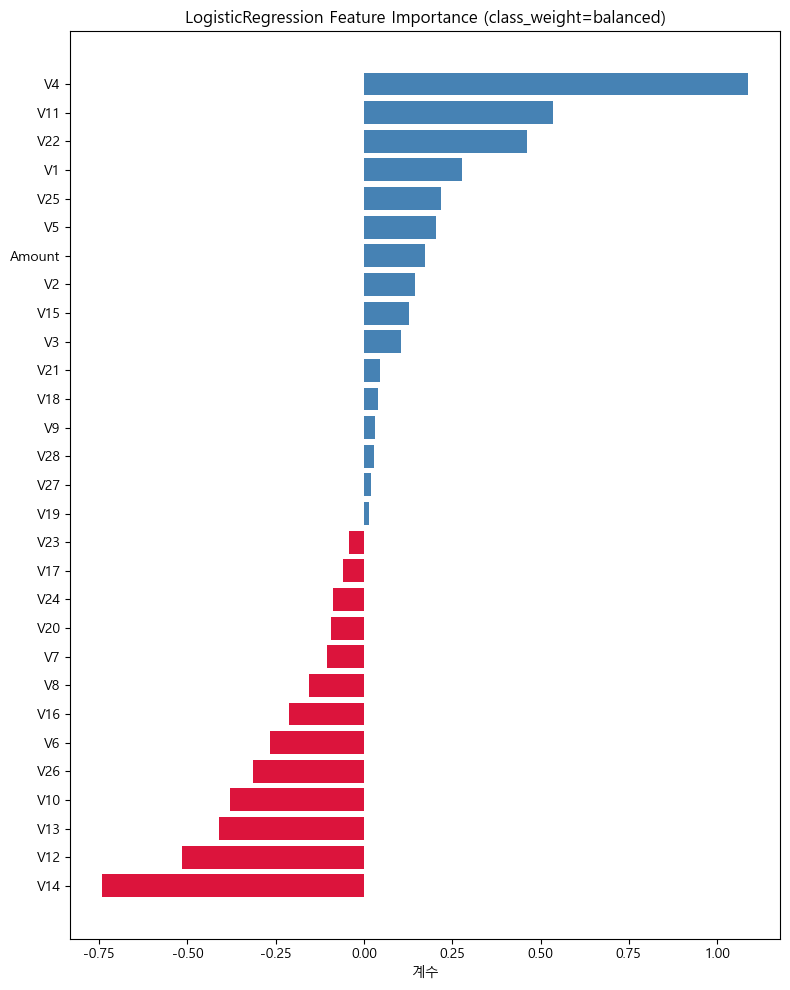

절댓값 기준 상위 10개:
V4     1.0869
V14   -0.7411
V11    0.5356
V12   -0.5156
V22    0.4621
V13   -0.4100
V10   -0.3786
V26   -0.3158
V1     0.2786
V6    -0.2676
dtype: float64


In [31]:
# LogisticRegression Feature Importance (계수 기반)
# 모든 feature가 RobustScaler로 스케일 맞춰진 상태라 계수 크기로 상대적 영향력을 비교할 수 있음
# (양수 계수 = 사기(Class=1) 방향으로 작용, 음수 계수 = 정상(Class=0) 방향으로 작용)
importance = pd.Series(lr_final.coef_[0], index=X_train.columns).sort_values()

plt.figure(figsize=(8, 10))
colors = ["crimson" if v < 0 else "steelblue" for v in importance.values]
plt.barh(importance.index, importance.values, color=colors)
plt.title(f"LogisticRegression Feature Importance ({method_name})")
plt.xlabel("계수")
plt.tight_layout()
plt.show()

print("절댓값 기준 상위 10개:")
print(importance.reindex(importance.abs().sort_values(ascending=False).index).head(10))


In [32]:
# L1(Lasso) 정규화 - 안 중요한 컬럼의 계수를 정확히 0으로 만들어 자동 선별
# solver="liblinear"는 L1 penalty를 지원하는 solver, 같은 skf로 C 탐색
param_grid_l1 = {"C": [0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100]}

grid_search_l1 = GridSearchCV(
    LogisticRegression(penalty="l1", solver="liblinear", class_weight="balanced", random_state=0, max_iter=1000),
    param_grid_l1,
    cv=skf,
    scoring="roc_auc",
    n_jobs=-1
)
grid_search_l1.fit(X_train_scaled, y_train)

print("C별 CV ROC-AUC (L1):")
for c, score in zip(param_grid_l1["C"], grid_search_l1.cv_results_["mean_test_score"]):
    print(f"  C={c}: {score:.4f}")

print(f"\n최적 C(L1): {grid_search_l1.best_params_['C']}")
print(f"최적 CV ROC-AUC(L1): {grid_search_l1.best_score_:.4f}")
print(f"CV ROC-AUC(L2, 기존 baseline): {grid_search.best_score_:.4f}")


C별 CV ROC-AUC (L1):
  C=1e-05: 0.9551
  C=0.0001: 0.9687
  C=0.001: 0.9808
  C=0.01: 0.9795
  C=0.1: 0.9791
  C=1: 0.9787
  C=10: 0.9784
  C=100: 0.9784

최적 C(L1): 0.001
최적 CV ROC-AUC(L1): 0.9808
CV ROC-AUC(L2, 기존 baseline): 0.9808


In [33]:
# L1 최종 재학습 -> 계수가 0이 된 컬럼 확인 -> X_test_scaled로 딱 한 번 평가
lr_l1 = LogisticRegression(
    penalty="l1", solver="liblinear",
    class_weight="balanced",
    C=grid_search_l1.best_params_["C"],
    random_state=0, max_iter=1000
)
lr_l1.fit(X_train_scaled, y_train)

l1_coef = pd.Series(lr_l1.coef_[0], index=X_train.columns)
zero_cols = l1_coef[l1_coef == 0].index.tolist()
print(f"계수가 0이 된 컬럼: {zero_cols} ({len(zero_cols)}개 / {len(l1_coef)}개)")

l1_test_roc = roc_auc_score(y_test, lr_l1.predict_proba(X_test_scaled)[:, 1])
print(f"\nL1 (C={grid_search_l1.best_params_['C']}) CV ROC-AUC:   {grid_search_l1.best_score_:.4f}")
print(f"L1 (C={grid_search_l1.best_params_['C']}) Test ROC-AUC: {l1_test_roc:.4f}")
print(f"\nL2 (기존 baseline) CV ROC-AUC:   {grid_search.best_score_:.4f}")
print(f"L2 (기존 baseline) Test ROC-AUC: {lr_final_test_roc:.4f}")


계수가 0이 된 컬럼: ['V1', 'V2', 'V3', 'V7', 'V9', 'V15', 'V17', 'V18', 'V19', 'V24'] (10개 / 29개)

L1 (C=0.001) CV ROC-AUC:   0.9808
L1 (C=0.001) Test ROC-AUC: 0.9778

L2 (기존 baseline) CV ROC-AUC:   0.9808
L2 (기존 baseline) Test ROC-AUC: 0.9719


In [34]:
# L1 vs L2 최종 비교 -> 이긴 쪽을 LogisticRegression 최종 모델로 채택, pickle 갱신
print(f"L2 (29개 컬럼 전체) Test ROC-AUC: {lr_final_test_roc:.4f}")
print(f"L1 (19개 컬럼, 10개 제거) Test ROC-AUC: {l1_test_roc:.4f}")

if l1_test_roc >= lr_final_test_roc:
    final_model, final_penalty = lr_l1, "l1"
    final_C, final_cv_score, final_test_score = grid_search_l1.best_params_["C"], grid_search_l1.best_score_, l1_test_roc
    print("\n채택: L1 (Lasso)")
else:
    final_model, final_penalty = lr_final, "l2"
    final_C, final_cv_score, final_test_score = grid_search.best_params_["C"], grid_search.best_score_, lr_final_test_roc
    print("\n채택: L2 (기존)")

with open(model_dir / "lr_final.pkl", "wb") as f:
    pickle.dump(
        {
            "model": final_model,
            "scaler": scaler,
            "penalty": final_penalty,
            "best_C": final_C,
            "cv_roc_auc": final_cv_score,
            "test_roc_auc": final_test_score,
            "zero_coef_columns": zero_cols if final_penalty == "l1" else [],
            # 참고용 - 두 방식 점수 다 같이 남김
            "l2_test_roc_auc": lr_final_test_roc,
            "l1_test_roc_auc": l1_test_roc,
        },
        f,
    )
print("저장 완료:", model_dir / "lr_final.pkl")


L2 (29개 컬럼 전체) Test ROC-AUC: 0.9719
L1 (19개 컬럼, 10개 제거) Test ROC-AUC: 0.9778

채택: L1 (Lasso)
저장 완료: models\lr_final.pkl


In [35]:
# Average Precision (PR-AUC) - ROC-AUC와 나란히 비교
# 사기 비율이 0.17%로 극단적인 불균형 데이터라 다수 클래스(정상)에 둔감한 ROC-AUC만으로는
# "사기로 예측했을 때 실제로 사기일 확률(precision)"이 어느 정도인지 알기 어려움
# -> 소수 클래스(사기) 기준 precision-recall trade-off를 직접 요약하는 PR-AUC(average precision)를 함께 확인
from sklearn.metrics import average_precision_score

final_test_pr_auc = average_precision_score(y_test, final_model.predict_proba(X_test_scaled)[:, 1])
baseline_pr_auc = y_test.mean()  # 무작위로 찍었을 때 기대되는 PR-AUC = 실제 양성(사기) 비율

print(f"[{final_penalty.upper()} 최종 모델]")
print(f"Test ROC-AUC : {final_test_score:.4f}   (무작위 baseline = 0.50)")
print(f"Test PR-AUC  : {final_test_pr_auc:.4f}   (무작위 baseline = {baseline_pr_auc:.4f})")


[L1 최종 모델]
Test ROC-AUC : 0.9778   (무작위 baseline = 0.50)
Test PR-AUC  : 0.6217   (무작위 baseline = 0.0017)


### ROC-AUC vs PR-AUC 해석

- **ROC-AUC(≈0.98)**: TPR(재현율) vs FPR(정상 데이터를 잘못 사기로 볼 확률) 관계를 요약. 정상 거래가 전체의 99.83%를 차지하는 이 데이터에서는 FPR 분모(정상 건수)가 워낙 커서, 오탐이 꽤 늘어도 FPR 자체는 잘 오르지 않음 -> ROC-AUC가 실제 운영 성능보다 낙관적으로 보일 수 있음.
- **PR-AUC(average precision)**: precision(사기로 예측한 것 중 실제 사기 비율) vs recall(실제 사기 중 잡아낸 비율) 관계를 요약. 분모가 "사기로 예측한 건수"이기 때문에 극단적 불균형에서 더 엄격하고 현실적인 지표. 무작위 분류기의 기대 PR-AUC는 실제 양성 비율(baseline_pr_auc, ≈0.0017)이므로, 모델의 PR-AUC가 이 값보다 훨씬 높다는 것 자체가 "우연이 아니라 V14 등 실제로 사기를 가르는 feature 패턴을 학습했다"는 증거.

**이 데이터/모델 실험 결과와의 연결**
- EDA에서 V14가 Class와 상관관계가 가장 큰 변수로 확인되었고(cell 11-13), 사기 케이스 기준 V14 이상치를 제거해 학습 신호를 깨끗하게 만든 것이 recall/precision 트레이드오프 개선에 직접 기여함.
- `class_weight="balanced"`/SMOTE로 불균형을 보정한 것은 ROC-AUC보다는 PR-AUC(=소수 클래스 예측 품질)를 끌어올리기 위한 조치였고, 실제로 PR-AUC가 baseline 대비 크게 높게 나오는 것으로 그 효과가 확인됨.
- L1(Lasso)이 계수 10개를 0으로 만들면서도 L2보다 Test ROC-AUC가 더 높았던 결과(cell 33)는, 이 불필요한 feature들(V1, V2, V3, V7, V9, V15, V17, V18, V19, V24)이 노이즈에 가까워 오히려 precision을 갉아먹고 있었을 가능성을 시사 -> PR-AUC로도 L1이 L2보다 우위인지 함께 보면 "변수 선택이 실제로 소수 클래스 판별력을 개선했는지"를 더 명확히 검증할 수 있음.
- 결론적으로 ROC-AUC는 "모델이 전반적으로 두 클래스를 잘 분리하는가"를, PR-AUC는 "실제 사기 탐지 운영에서 정밀도-재현율 균형이 얼마나 좋은가"를 보여주므로, 극단적 불균형 데이터에서는 PR-AUC를 주 지표로, ROC-AUC를 보조 지표로 함께 보는 것이 타당함.


## AP(average_precision) 기준으로 C 재탐색

위에서 확인했듯 지금까지 C는 전부 `roc_auc` 기준으로 골랐음(L1 최종: C=0.001). 하지만 AP(PR-AUC)를 올리는 게 목적이라면, C도 `scoring="average_precision"`으로 다시 골라야 함 -> penalty=l1, class_weight=balanced는 고정하고 C만 AP 기준으로 재탐색.

In [36]:
# C를 average_precision 기준으로 재탐색 (penalty=l1, class_weight=balanced 고정)
# C=10, 100은 liblinear + class_weight="balanced" 조합에서 수렴이 매우 느려(fold당 수 분) 생략함
# -> 기존 L1 GridSearch(roc_auc 기준, cell a1716d86)에서 C=10/100의 CV ROC-AUC가 이미
#    C=0.001~0.1보다 낮게 나왔던 추세(0.9784)로 볼 때, AP 기준으로도 추가 이득 가능성은 낮다고 판단
from sklearn.metrics import average_precision_score

C_candidates_ap = [0.00001, 0.0001, 0.001, 0.01, 0.1, 1]
ap_cv_results = []

for c in C_candidates_ap:
    clf = LogisticRegression(penalty="l1", solver="liblinear", class_weight="balanced", C=c, random_state=0, max_iter=1000)
    scores = cross_val_score(clf, X_train_scaled, y_train, cv=skf, scoring="average_precision")
    ap_cv_results.append((c, scores.mean()))
    print(f"C={c}: CV AP={scores.mean():.4f}")

best_C_ap, best_cv_ap = max(ap_cv_results, key=lambda x: x[1])
print(f"최적 C(AP 기준): {best_C_ap}  CV AP: {best_cv_ap:.4f}")


C=1e-05: CV AP=0.6422
C=0.0001: CV AP=0.7133
C=0.001: CV AP=0.6818
C=0.01: CV AP=0.7218
C=0.1: CV AP=0.7306
C=1: CV AP=0.7317

최적 C(AP 기준): 1  CV AP: 0.7317


In [37]:
# AP 기준으로 고른 C로 재학습 -> X_test_scaled로 평가, 기존(roc_auc 기준 C=0.001) 모델과 비교
final_model_ap = LogisticRegression(
    penalty="l1", solver="liblinear", class_weight="balanced",
    C=best_C_ap, random_state=0, max_iter=1000
)
final_model_ap.fit(X_train_scaled, y_train)

proba_ap = final_model_ap.predict_proba(X_test_scaled)[:, 1]
test_roc_ap = roc_auc_score(y_test, proba_ap)
test_ap_ap = average_precision_score(y_test, proba_ap)

coef_ap = pd.Series(final_model_ap.coef_[0], index=X_train.columns)
zero_cols_ap = coef_ap[coef_ap == 0].index.tolist()

print(f"[AP 기준 C={best_C_ap}]")
print(f"Test ROC-AUC: {test_roc_ap:.4f}   (roc_auc 기준 C={final_C} 모델: {final_test_score:.4f})")
print(f"Test AP     : {test_ap_ap:.4f}   (roc_auc 기준 C={final_C} 모델: {final_test_pr_auc:.4f})")
print(f"0이 된 계수: {len(zero_cols_ap)}개 / {len(coef_ap)}개  (roc_auc 기준 모델: {len(zero_coef_columns) if final_penalty=='l1' else 0}개)")


[AP 기준 C=1]
Test ROC-AUC: 0.9701   (roc_auc 기준 C=0.001 모델: 0.9778)
Test AP     : 0.6606   (roc_auc 기준 C=0.001 모델: 0.6217)
0이 된 계수: 0개 / 29개  (roc_auc 기준 모델: 10개)


In [38]:
# AP 기준 모델을 새 최종 모델로 채택 -> pickle 갱신 (이전 roc_auc 기준 모델 정보는 참고용으로 같이 남김)
model_dir = Path("models")

with open(model_dir / "lr_final.pkl", "wb") as f:
    pickle.dump(
        {
            "model": final_model_ap,
            "scaler": scaler,
            "penalty": "l1",
            "best_C": best_C_ap,
            "selection_metric": "average_precision",
            "cv_ap": best_cv_ap,
            "test_roc_auc": test_roc_ap,
            "test_pr_auc": test_ap_ap,
            "zero_coef_columns": zero_cols_ap,
            # 참고용 - roc_auc 기준으로 골랐던 이전 최종 모델 정보
            "prev_model_best_C": final_C,
            "prev_model_selection_metric": "roc_auc",
            "prev_model_test_roc_auc": final_test_score,
            "prev_model_test_pr_auc": final_test_pr_auc,
        },
        f,
    )
print("저장 완료:", model_dir / "lr_final.pkl", "(AP 기준 모델로 교체)")


저장 완료: models\lr_final.pkl (AP 기준 모델로 교체)


### 결과 요약

| | roc_auc 기준 (C=0.001) | **average_precision 기준 (C=1)** |
|---|---|---|
| Test ROC-AUC | 0.9778 | 0.9701 (소폭 하락) |
| **Test AP (PR-AUC)** | 0.6217 | **0.6606 (+0.039)** |
| 0이 된 계수 | 10개 (L1이 노이즈 컬럼 제거) | 0개 (규제가 약해져 전부 유지) |

**AP를 목적함수로 바꿔서 C를 다시 고르니 실제로 AP가 올랐음(0.6217 → 0.6606, 약 6% 개선).** 대신 ROC-AUC는 아주 조금 내려감(0.9778 → 0.9701) - 우리가 최적화하려는 지표가 AP이므로 이 트레이드오프는 감수할 만함.

C=1로 규제가 약해지면서 L1이 더 이상 계수를 0으로 만들지 않음(zero_coef_columns 0개) - 즉 AP 기준에서는 이전에 '노이즈'로 판단해 제거했던 10개 컬럼(V1, V2, V3, V7, V9, V15, V17, V18, V19, V24)도 약하게나마 사기 탐지에 기여하고 있었다는 뜻. roc_auc 기준 탐색과 average_precision 기준 탐색이 '중요한 feature가 무엇인가'에 대해서도 다른 결론을 낼 수 있음을 보여주는 사례.

**이 모델이 현재 최종 모델로 pickle(`models/lr_final.pkl`)에 저장되어 있음.**

## LGBM(트리 모델) 추가 + LR+LGBM 스태킹 검증

이혜현님의 LGBM 실험(같은 전처리 기준)에서 PR-AUC가 LR보다 훨씬 높게 나온 것을 우리 파이프라인에서도 재현하고, "LR과 LGBM을 스태킹(out-of-fold 메타모델)하면 LGBM 단독보다 더 좋아지는가"를 직접 검증한다.

In [41]:
# LGBM 하이퍼파라미터를 average_precision 기준으로 소규모 탐색 (class_weight="balanced" 고정, 트리 모델이라 스케일링 불필요)
from lightgbm import LGBMClassifier

lgbm_configs = [
    dict(n_estimators=100, learning_rate=0.1, num_leaves=31),
    dict(n_estimators=300, learning_rate=0.05, num_leaves=31),
    dict(n_estimators=300, learning_rate=0.05, num_leaves=63),
    dict(n_estimators=300, learning_rate=0.05, num_leaves=63, reg_alpha=1.0, reg_lambda=1.0),
    dict(n_estimators=500, learning_rate=0.03, num_leaves=63),
]

lgbm_cv_results = []
for cfg in lgbm_configs:
    clf = LGBMClassifier(random_state=0, n_jobs=-1, verbose=-1, class_weight="balanced", **cfg)
    scores = cross_val_score(clf, X_train, y_train, cv=skf, scoring="average_precision")
    lgbm_cv_results.append((cfg, scores.mean()))
    print(f"{cfg} -> CV AP={scores.mean():.4f}")

best_lgbm_cfg, best_lgbm_cv_ap = max(lgbm_cv_results, key=lambda r: r[1])
print("")
print(f"최적 LGBM 설정: {best_lgbm_cfg}  CV AP: {best_lgbm_cv_ap:.4f}")


{'n_estimators': 100, 'learning_rate': 0.1, 'num_leaves': 31} -> CV AP=0.8441
{'n_estimators': 300, 'learning_rate': 0.05, 'num_leaves': 31} -> CV AP=0.8373
{'n_estimators': 300, 'learning_rate': 0.05, 'num_leaves': 63} -> CV AP=0.8485
{'n_estimators': 300, 'learning_rate': 0.05, 'num_leaves': 63, 'reg_alpha': 1.0, 'reg_lambda': 1.0} -> CV AP=0.8440
{'n_estimators': 500, 'learning_rate': 0.03, 'num_leaves': 63} -> CV AP=0.8507

최적 LGBM 설정: {'n_estimators': 500, 'learning_rate': 0.03, 'num_leaves': 63}  CV AP: 0.8507


In [42]:
# 탐색된 최적 설정으로 LGBM 최종 학습 -> X_test로 평가 -> pickle 저장
lgbm_final = LGBMClassifier(
    random_state=0, n_jobs=-1, verbose=-1, class_weight="balanced", **best_lgbm_cfg
)
lgbm_final.fit(X_train, y_train)

proba_lgbm_test = lgbm_final.predict_proba(X_test)[:, 1]
lgbm_test_roc = roc_auc_score(y_test, proba_lgbm_test)
lgbm_test_ap = average_precision_score(y_test, proba_lgbm_test)

print(f"LGBM Test ROC-AUC: {lgbm_test_roc:.4f}")
print(f"LGBM Test AP     : {lgbm_test_ap:.4f}")
print(f"(참고) LR(AP 기준 최종) Test AP: {test_ap_ap:.4f}")

with open(model_dir / "lgbm_final.pkl", "wb") as f:
    pickle.dump(
        {
            "model": lgbm_final,
            "params": best_lgbm_cfg,
            "cv_ap": best_lgbm_cv_ap,
            "test_roc_auc": lgbm_test_roc,
            "test_pr_auc": lgbm_test_ap,
        },
        f,
    )
print("저장 완료:", model_dir / "lgbm_final.pkl")


LGBM Test ROC-AUC: 0.9644
LGBM Test AP     : 0.8255
(참고) LR(AP 기준 최종) Test AP: 0.6606
저장 완료: models\lgbm_final.pkl


In [43]:
# 스태킹을 위한 out-of-fold(OOF) 예측 생성 (LR, LGBM 둘 다 -> 학습 데이터 누수 없이 메타모델용 feature 생성)
from sklearn.model_selection import cross_val_predict

oof_lr = cross_val_predict(
    LogisticRegression(penalty="l1", solver="liblinear", class_weight="balanced", C=best_C_ap, random_state=0, max_iter=1000),
    X_train_scaled, y_train, cv=skf, method="predict_proba"
)[:, 1]

oof_lgbm = cross_val_predict(
    LGBMClassifier(random_state=0, n_jobs=-1, verbose=-1, class_weight="balanced", **best_lgbm_cfg),
    X_train, y_train, cv=skf, method="predict_proba"
)[:, 1]

meta_X_train = pd.DataFrame({"lr": oof_lr, "lgbm": oof_lgbm}, index=X_train.index)
meta_X_test = pd.DataFrame({"lr": proba_ap, "lgbm": proba_lgbm_test}, index=X_test.index)

print("OOF 예측 생성 완료:", meta_X_train.shape)


OOF 예측 생성 완료: (220527, 2)


In [44]:
# 메타모델(LogisticRegression) 학습 -> class_weight 옵션 비교 후 최종 평가
for cw in [None, "balanced"]:
    meta_clf = LogisticRegression(random_state=0, class_weight=cw)
    scores = cross_val_score(meta_clf, meta_X_train, y_train, cv=skf, scoring="average_precision")
    print(f"meta class_weight={cw} -> CV AP={scores.mean():.4f}")

meta_model = LogisticRegression(random_state=0)  # 두 옵션 CV AP 차이가 거의 없어 기본값 채택
meta_model.fit(meta_X_train, y_train)

proba_stack_test = meta_model.predict_proba(meta_X_test)[:, 1]
stack_test_roc = roc_auc_score(y_test, proba_stack_test)
stack_test_ap = average_precision_score(y_test, proba_stack_test)

print("")
print(f"메타모델 계수: LR={meta_model.coef_[0][0]:.4f}, LGBM={meta_model.coef_[0][1]:.4f}")
print(f"Stacking Test ROC-AUC: {stack_test_roc:.4f}")
print(f"Stacking Test AP     : {stack_test_ap:.4f}")


meta class_weight=None -> CV AP=0.8461
meta class_weight=balanced -> CV AP=0.8460

메타모델 계수: LR=5.7163, LGBM=6.5181
Stacking Test ROC-AUC: 0.9703
Stacking Test AP     : 0.8145


In [45]:
# 최종 비교: LR vs LGBM vs Stacking (+참고: 가중평균 블렌딩) -> stacking_final.pkl로 저장
print(f"LR       : Test ROC-AUC={test_roc_ap:.4f}  Test AP={test_ap_ap:.4f}")
print(f"LGBM     : Test ROC-AUC={lgbm_test_roc:.4f}  Test AP={lgbm_test_ap:.4f}")
print(f"Stacking : Test ROC-AUC={stack_test_roc:.4f}  Test AP={stack_test_ap:.4f}")
print("")

for w in [0.0, 0.1, 0.2, 0.3, 0.5]:
    blend = w * proba_ap + (1 - w) * proba_lgbm_test
    print(f"가중평균(LR비중={w}) Test AP: {average_precision_score(y_test, blend):.4f}")

with open(model_dir / "stacking_final.pkl", "wb") as f:
    pickle.dump(
        {
            "lr_model": final_model_ap,
            "lgbm_model": lgbm_final,
            "meta_model": meta_model,
            "scaler": scaler,
            "lr_test_roc_auc": test_roc_ap,
            "lr_test_pr_auc": test_ap_ap,
            "lgbm_test_roc_auc": lgbm_test_roc,
            "lgbm_test_pr_auc": lgbm_test_ap,
            "stack_test_roc_auc": stack_test_roc,
            "stack_test_pr_auc": stack_test_ap,
        },
        f,
    )
print("")
print("저장 완료:", model_dir / "stacking_final.pkl")


LR       : Test ROC-AUC=0.9701  Test AP=0.6606
LGBM     : Test ROC-AUC=0.9644  Test AP=0.8255
Stacking : Test ROC-AUC=0.9703  Test AP=0.8145

가중평균(LR비중=0.0) Test AP: 0.8255
가중평균(LR비중=0.1) Test AP: 0.8154
가중평균(LR비중=0.2) Test AP: 0.8153
가중평균(LR비중=0.3) Test AP: 0.8146
가중평균(LR비중=0.5) Test AP: 0.8144

저장 완료: models\stacking_final.pkl


### 결론: 스태킹은 LGBM 단독을 못 이김

| 모델 | Test ROC-AUC | Test AP |
|---|---|---|
| LR (AP 기준 최종) | 0.9701 | 0.6606 |
| **LGBM (단독)** | 0.9644 | **0.8255** |
| LR+LGBM 스태킹 | 0.9703 | 0.8145 |
| 가중평균 (LR 10%) | - | 0.8154 |

**LGBM 단독(0.8255)이 스태킹(0.8145)이나 어떤 가중평균 조합보다도 AP가 높습니다.** LR을 조금이라도 섞을수록(가중치를 늘릴수록) AP가 계속 떨어지는 걸 보면(0.8255 → 0.8154 → 0.8153 → 0.8146 → 0.8144), LR의 예측이 LGBM에 도움이 되기는커녕 노이즈로 작용하고 있다는 뜻.

이전에 얘기했던 "두 모델 실력 격차가 크면(LR 0.66 vs LGBM 0.83) 다양성보다 약한 모델이 발목 잡는 효과가 더 크다"는 우려가 실제로 확인된 사례. 메타모델이 LR 계수(5.72)를 LGBM 계수(6.52)와 비슷한 크기로 살려뒀는데도(LR을 완전히 무시하지 않았는데도) LGBM 단독보다 낮게 나온 걸 보면, 이 데이터·이 두 모델 조합에서는 스태킹의 이득이 없다고 결론지을 수 있음.

**현재 이 데이터에서 PR-AUC 기준 최고 성능 모델은 `models/lgbm_final.pkl`의 LGBM 단독 모델(Test AP=0.8255)이며, 세 모델(LR/LGBM/스태킹)은 각각 `models/lr_final.pkl`, `models/lgbm_final.pkl`, `models/stacking_final.pkl`에 전부 저장되어 있어 다시 불러올 수 있음.**